# CIC-IDS2017 -- Class Distribution Analysis

## Objectives

- Analyze the overall distribtuin of traffic classes
- Compare benign and attack traffic
- Analyze individual attack classes
- Exmaine class distributions within each source file
- Identify rare and severely underrepresented classes
- Quantify class imbalance
- Determine which attack classes are present in each capture file
- Produce CSV summaries and visualizations for later dataset comparison

> This notebook is descriptive only. No classes are removed, merged, undersampled, oversampled, or otherwise transformed.

## 1. Imports and Configuration

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = Path("../data/raw/cicids2017")
RESULTS_DIR = Path("../results/cicids2017/03_class_distribution")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files")

Found 8 CSV files


## 2. Load the files

In [2]:
dfs = {}

for file in csv_files:
    print(f"Loading: {file.name}")

    df = pd.read_csv(file, low_memory=False)

    # Normalize column names
    df.columns = df.columns.str.strip()
    dfs[file.name] = df

print("\nLoaded files:")
for name, df in dfs.items():
    print(f"{name}: {df.shape}")

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv

Loaded files:
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)


## 3. Identify the label column

In [3]:
label_candidates = [
    col for col in next(iter(dfs.values())).columns
    if "label" in col.lower()
]

label_candidates

['Label']

In [4]:
LABEL_COL = label_candidates[0]
print("Label column:", LABEL_COL)

Label column: Label


## 4. Create combined dataset with source information

In [5]:
data = pd.concat(
    [
        df.assign(source_file=name)
        for name, df in dfs.items()
    ],
    ignore_index=True
)

print("Combined shape:", data.shape)

Combined shape: (2830743, 80)


### Check labels

In [7]:
print("Unique classes:", data[LABEL_COL].nunique())
print("\nClasses:")
print(sorted(data[LABEL_COL].unique()))

Unique classes: 15

Classes:
['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


## 5. Overall Class Distribution

In [8]:
class_counts = (
    data[LABEL_COL]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="count")
)

class_counts["percentage"] = (
    class_counts["count"] / len(data) * 100
)

class_counts

,Class,count,percentage
0,BENIGN,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695


Sorting explicitly:

In [9]:
class_counts = class_counts.sort_values(
    "count",
    ascending=False
).reset_index(drop=True)

class_counts

,Class,count,percentage
0,BENIGN,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695


## 6. Visualize Overall Distribution

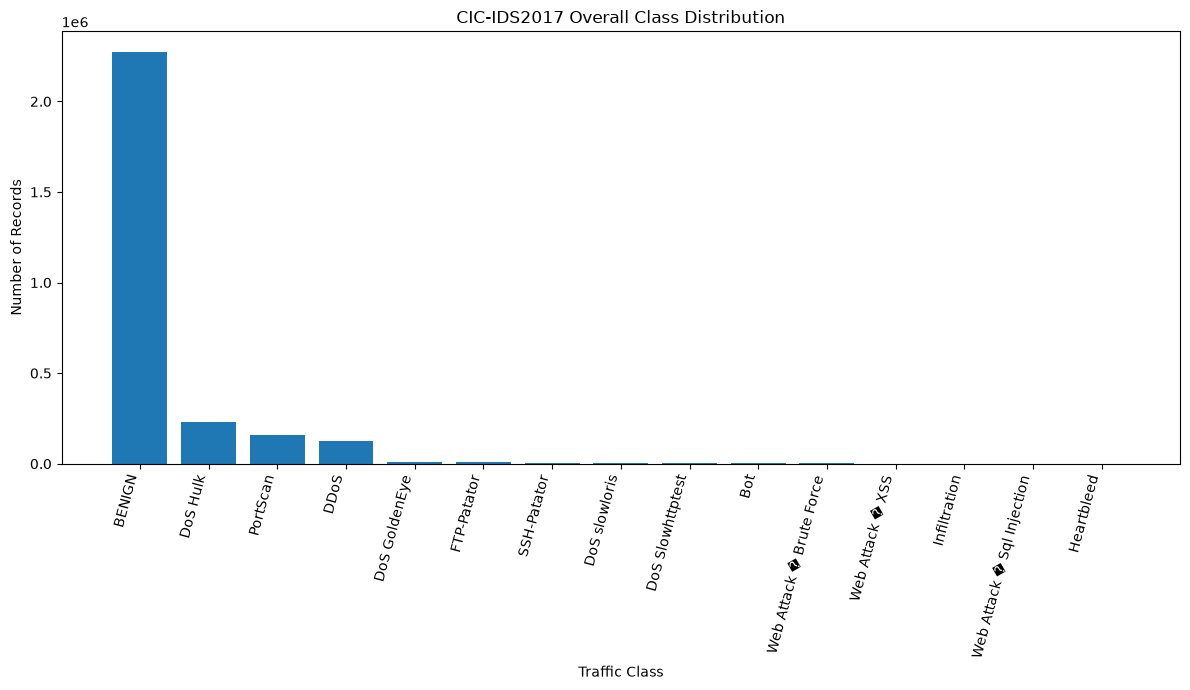

In [11]:
plt.figure(figsize=(12,7))

plt.bar(
    class_counts["Class"],
    class_counts["count"]
)

plt.title("CIC-IDS2017 Overall Class Distribution")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

## 7. BENIGN vs Attack Distribution

In [12]:
data["traffic_type"] = np.where(
    data[LABEL_COL].str.upper() == "BENIGN",
    "BENIGN",
    "ATTACK"
)

In [13]:
traffic_counts = (
    data["traffic_type"]
    .value_counts()
    .rename_axis("traffic_type")
    .reset_index(name="count")
)

traffic_counts["percentage"] = (
    traffic_counts["count"] / len(data) * 100
)

traffic_counts

,traffic_type,count,percentage
0,BENIGN,2273097,80.3004
1,ATTACK,557646,19.6996


Visualization

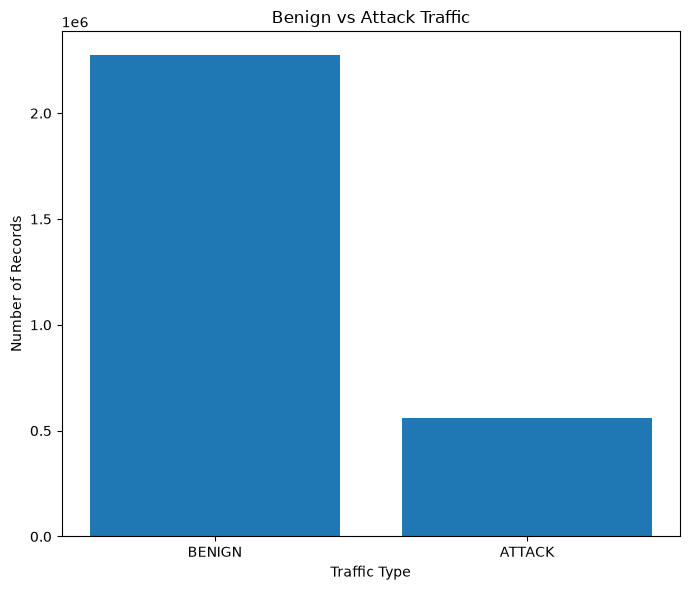

In [14]:
plt.figure(figsize=(7, 6))

plt.bar(
    traffic_counts["traffic_type"],
    traffic_counts["count"]
)

plt.title("Benign vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## 8. Attack-Only Distribution

In [15]:
attack_data = data[
    data["traffic_type"] == "ATTACK"
].copy()

print("Attack Records:", len(attack_data))

Attack Records: 557646


In [16]:
attack_counts = (
    attack_data[LABEL_COL]
    .value_counts()
    .rename_axis("attack_class")
    .reset_index(name="count")
)

attack_counts["percentage_of_attacks"] = (
    attack_counts["count"] / len(attack_data) * 100
)

attack_counts

,attack_class,count,percentage_of_attacks
0,DoS Hulk,231073,41.4372
1,PortScan,158930,28.5002
2,DDoS,128027,22.9585
3,DoS GoldenEye,10293,1.8458
4,FTP-Patator,7938,1.4235
5,SSH-Patator,5897,1.0575
6,DoS slowloris,5796,1.0394
7,DoS Slowhttptest,5499,0.9861
8,Bot,1966,0.3526
9,Web Attack � Brute Force,1507,0.2702


Visualize:

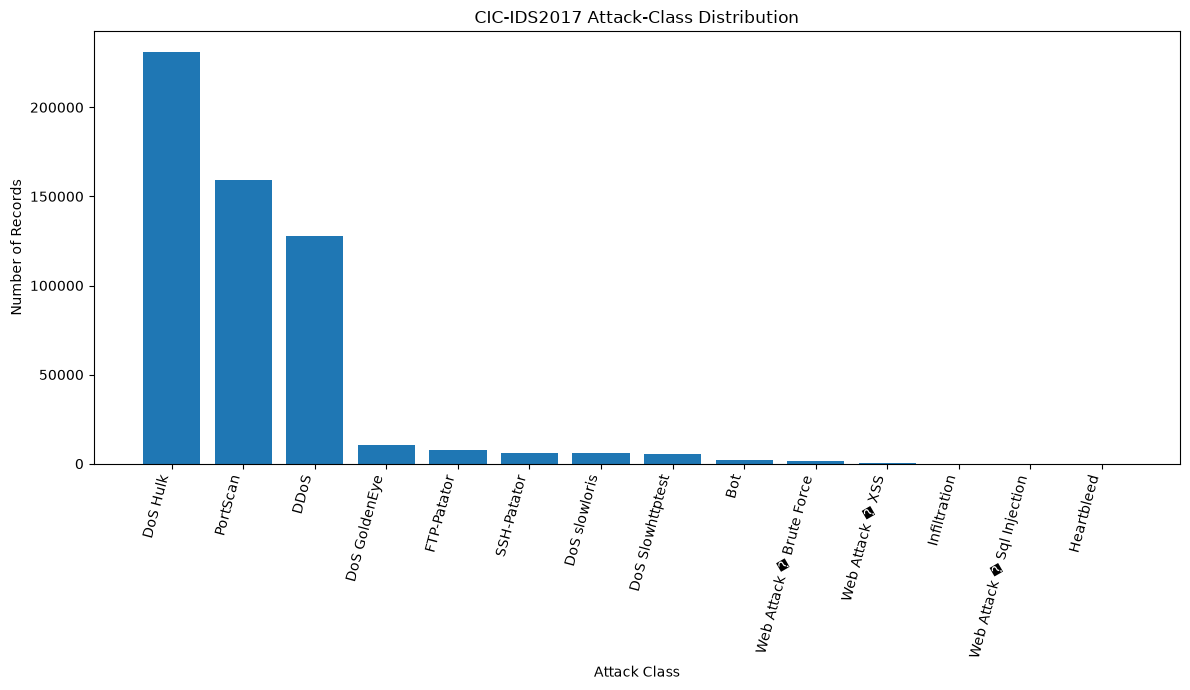

In [17]:
plt.figure(figsize=(12, 7))

plt.bar(
    attack_counts["attack_class"],
    attack_counts["count"]
)

plt.title("CIC-IDS2017 Attack-Class Distribution")
plt.xlabel("Attack Class")
plt.ylabel("Number of Records")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

## 9. Log-scale Attack Distribution

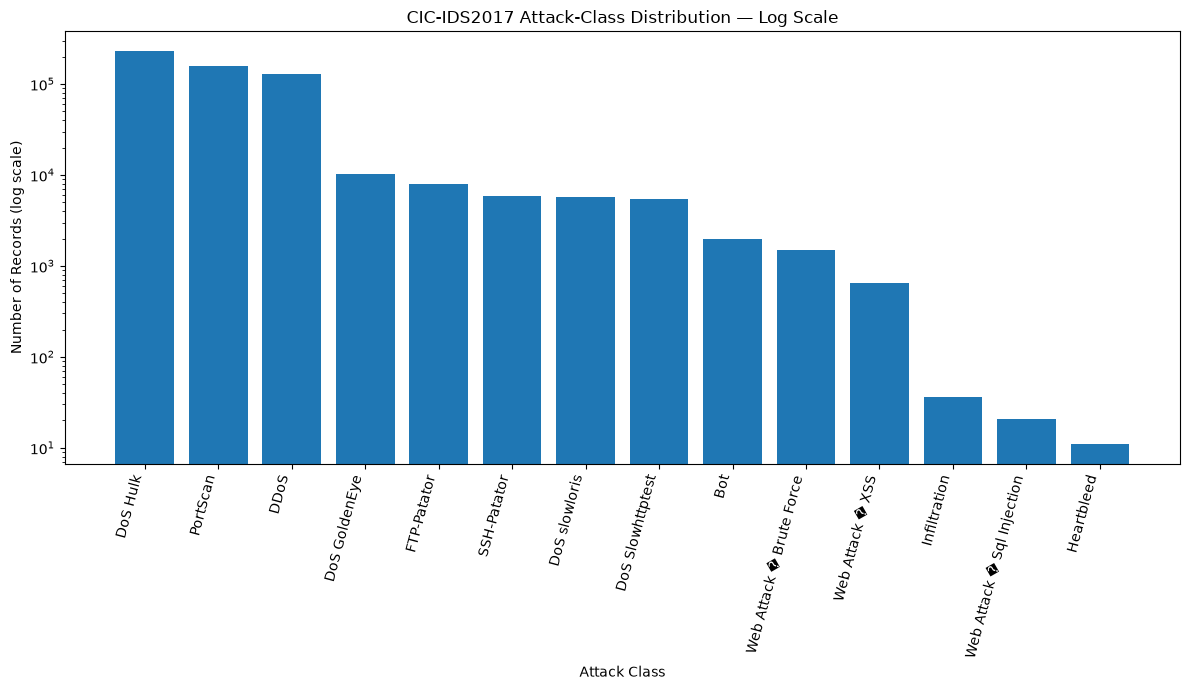

In [18]:
plt.figure(figsize=(12, 7))

plt.bar(
    attack_counts["attack_class"],
    attack_counts["count"]
)

plt.yscale("log")

plt.title("CIC-IDS2017 Attack-Class Distribution — Log Scale")
plt.xlabel("Attack Class")
plt.ylabel("Number of Records (log scale)")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

## 10. Per-file Class Distribution

In [19]:
per_file_counts = (
    data.groupby(
        ["source_file", LABEL_COL]
    )
    .size()
    .reset_index(name="count")
)

per_file_counts

,source_file,Label,count
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN,97718
1,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,DDoS,128027
2,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,BENIGN,127537
3,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,PortScan,158930
4,Friday-WorkingHours-Morning.pcap_ISCX.csv,BENIGN,189067
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,Bot,1966
6,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,529918
7,Thursday-WorkingHours-Afternoon-Infilteration....,BENIGN,288566
8,Thursday-WorkingHours-Afternoon-Infilteration....,Infiltration,36
9,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,BENIGN,168186


In [20]:
per_file_counts["percentage"] = (
    per_file_counts["count"]
    /
    per_file_counts.groupby("source_file")["count"].transform("sum")
    * 100
)

per_file_counts

,source_file,Label,count,percentage
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN,97718,43.2869
1,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,DDoS,128027,56.7131
2,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,BENIGN,127537,44.5207
3,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,PortScan,158930,55.4793
4,Friday-WorkingHours-Morning.pcap_ISCX.csv,BENIGN,189067,98.9709
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,Bot,1966,1.0291
6,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,529918,100.0000
7,Thursday-WorkingHours-Afternoon-Infilteration....,BENIGN,288566,99.9875
8,Thursday-WorkingHours-Afternoon-Infilteration....,Infiltration,36,0.0125
9,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,BENIGN,168186,98.7204


# 11. Per-file Distribution Matrix

In [21]:
per_file_matrix = (
    data.groupby(["source_file", LABEL_COL])
    .size()
    .unstack(fill_value=0)
)

per_file_matrix

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack � Brute Force,Web Attack � Sql Injection,Web Attack � XSS
source_file,,,,,,,,,,,,,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,97718,0,128027,0,0,0,0,0,0,0,0,0,0,0,0
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,127537,0,0,0,0,0,0,0,0,0,158930,0,0,0,0
Friday-WorkingHours-Morning.pcap_ISCX.csv,189067,1966,0,0,0,0,0,0,0,0,0,0,0,0,0
Monday-WorkingHours.pcap_ISCX.csv,529918,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,288566,0,0,0,0,0,0,0,0,36,0,0,0,0,0
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,168186,0,0,0,0,0,0,0,0,0,0,0,1507,21,652
Tuesday-WorkingHours.pcap_ISCX.csv,432074,0,0,0,0,0,0,7938,0,0,0,5897,0,0,0
Wednesday-workingHours.pcap_ISCX.csv,440031,0,0,10293,231073,5499,5796,0,11,0,0,0,0,0,0


In [22]:
per_file_percentage = (
    per_file_matrix
    .div(per_file_matrix.sum(axis=1), axis=0)
    * 100
)

per_file_percentage

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack � Brute Force,Web Attack � Sql Injection,Web Attack � XSS
source_file,,,,,,,,,,,,,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,43.2869,0.0000,56.7131,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,44.5207,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,55.4793,0.0000,0.0000,0.0000,0.0000
Friday-WorkingHours-Morning.pcap_ISCX.csv,98.9709,1.0291,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Monday-WorkingHours.pcap_ISCX.csv,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,99.9875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0125,0.0000,0.0000,0.0000,0.0000,0.0000
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,98.7204,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8846,0.0123,0.3827
Tuesday-WorkingHours.pcap_ISCX.csv,96.8973,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.7802,0.0000,0.0000,0.0000,1.3225,0.0000,0.0000,0.0000
Wednesday-workingHours.pcap_ISCX.csv,63.5238,0.0000,0.0000,1.4859,33.3582,0.7938,0.8367,0.0000,0.0016,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 12. Class Presence Matrix

In [23]:
class_presence = (
    per_file_matrix
    .gt(0)
    .astype(int)
)

class_presence

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack � Brute Force,Web Attack � Sql Injection,Web Attack � XSS
source_file,,,,,,,,,,,,,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
Friday-WorkingHours-Morning.pcap_ISCX.csv,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
Monday-WorkingHours.pcap_ISCX.csv,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1
Tuesday-WorkingHours.pcap_ISCX.csv,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0
Wednesday-workingHours.pcap_ISCX.csv,1,0,0,1,1,1,1,0,1,0,0,0,0,0,0


In [24]:
class_presence_display = class_presence.replace({
    0: "No",
    1: "Yes"
})

class_presence_display

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack � Brute Force,Web Attack � Sql Injection,Web Attack � XSS
source_file,,,,,,,,,,,,,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,Yes,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,Yes,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No
Friday-WorkingHours-Morning.pcap_ISCX.csv,Yes,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No
Monday-WorkingHours.pcap_ISCX.csv,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,Yes,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,Yes,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes
Tuesday-WorkingHours.pcap_ISCX.csv,Yes,No,No,No,No,No,No,Yes,No,No,No,Yes,No,No,No
Wednesday-workingHours.pcap_ISCX.csv,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,No,No,No,No,No,No


## 13. Number of Files Containing Each Class

In [25]:
class_file_presence = (
    class_presence
    .sum(axis=0)
    .sort_values(ascending=False)
    .rename("files_present")
    .reset_index()
    .rename(columns={"index": "class"})
)

class_file_presence

,Label,files_present
0,BENIGN,8
1,Bot,1
2,DDoS,1
3,DoS GoldenEye,1
4,DoS Hulk,1
5,DoS Slowhttptest,1
6,DoS slowloris,1
7,FTP-Patator,1
8,Heartbleed,1
9,Infiltration,1


## 14. Class Imbalance Metrics

Majority / Minority

In [27]:
majority_count = class_counts["count"].max()
minority_count = class_counts["count"].min()

majority_class = class_counts.iloc[0]["Class"]
minority_class = class_counts.iloc[-1]["Class"]

imbalance_ratio = majority_count / minority_count

print("Majority Class:", majority_class)
print("Majority Count:", majority_count)

print("\nMinority Class:", minority_class)
print("Minority Count:", minority_count)

print("\nMajority / Minority Ratio:", imbalance_ratio)

Majority Class: BENIGN
Majority Count: 2273097

Minority Class: Heartbleed
Minority Count: 11

Majority / Minority Ratio: 206645.18181818182


## 15. Attack-Class Imbalance

In [29]:
attack_majority = attack_counts["count"].max()
attack_minority = attack_counts["count"].min()

attack_majority_class = attack_counts.iloc[0]["attack_class"]
attack_minority_class = attack_counts.iloc[-1]["attack_class"]

attack_imbalance_ratio = (
    attack_majority / attack_minority
)

print("Most common attack:", attack_majority_class)
print("Most common attack count:", attack_majority)

print("\nRarest attack:", attack_minority_class)
print("Rarest attack count:", attack_minority)

print(
    "\nAttack-Class Imbalance Ratio:",
    attack_imbalance_ratio
)

Most common attack: DoS Hulk
Most common attack count: 231073

Rarest attack: Heartbleed
Rarest attack count: 11

Attack-Class Imbalance Ratio: 21006.636363636364


## 16. Rare Classes

In [30]:
RARE_THRESHOLD = 1000

rare_classes = attack_counts[
    attack_counts["count"] < RARE_THRESHOLD
].copy()

rare_classes

,attack_class,count,percentage_of_attacks
10,Web Attack � XSS,652,0.1169
11,Infiltration,36,0.0065
12,Web Attack � Sql Injection,21,0.0038
13,Heartbleed,11,0.0020


In [31]:
print(
    f"Attack classes with fewer than {RARE_THRESHOLD:,} records:",
    len(rare_classes)
)

Attack classes with fewer than 1,000 records: 4


## 17. Class distribution by source file - Visualization

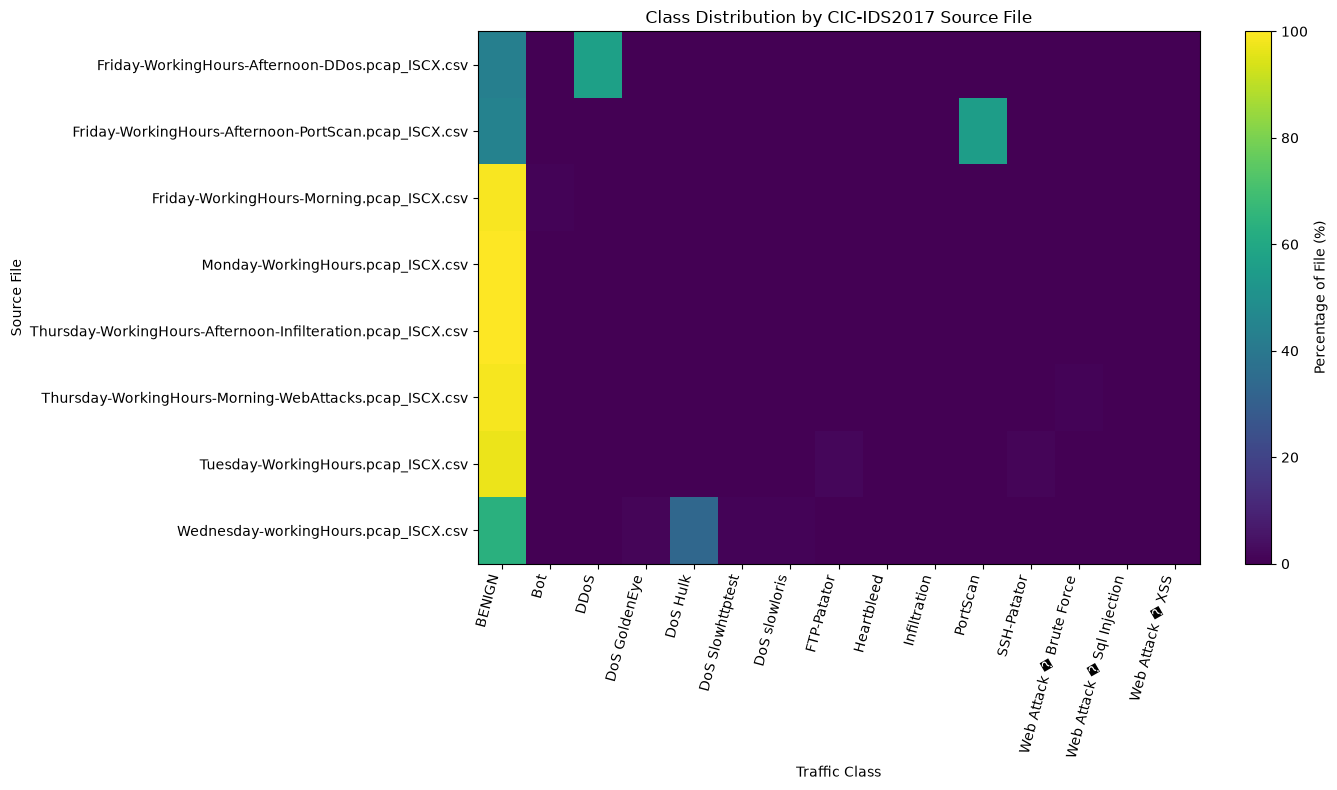

In [32]:
matrix = per_file_percentage.values

plt.figure(figsize=(14, 8))

plt.imshow(
    matrix, aspect="auto"
)

plt.colorbar(label="Percentage of File (%)")

plt.xticks(
    range(len(per_file_percentage.columns)),
    per_file_percentage.columns,
    rotation=75,
    ha="right"
)

plt.yticks(
    range(len(per_file_percentage.index)),
    per_file_percentage.index
)

plt.title("Class Distribution by CIC-IDS2017 Source File")
plt.xlabel("Traffic Class")
plt.ylabel("Source File")

plt.tight_layout()
plt.show()

## 18. Export Results

In [35]:
class_counts.to_csv(
    RESULTS_DIR / "overall_class_distribution.csv",
    index=False
)

attack_counts.to_csv(
    RESULTS_DIR / "attack_class_distribution.csv",
    index=False
)

per_file_counts.to_csv(
    RESULTS_DIR / "per_file_class_distribution.csv",
    index=False
)

class_presence.to_csv(
    RESULTS_DIR / "class_presence_matrix.csv",
)

class_file_presence.to_csv(
    RESULTS_DIR / "class_file_presence.csv",
    index=False
)

Imbalance Summary

In [36]:
imbalance_summary = pd.DataFrame({
    "metric": [
        "total_records",
        "number_of_classes",
        "majority_class",
        "majority_count",
        "minority_class",
        "minority_count",
        "overall_imbalance_ratio",
        "total_attack_records",
        "number_of_attack_classes",
        "most_common_attack",
        "most_common_attack_count",
        "rarest_attack",
        "rarest_attack_count",
        "attack_imbalance_ratio"
    ],
    "value": [
        len(data),
        data[LABEL_COL].nunique(),
        majority_class,
        majority_count,
        minority_class,
        minority_count,
        imbalance_ratio,
        len(attack_data),
        attack_counts.shape[0],
        attack_majority_class,
        attack_majority,
        attack_minority_class,
        attack_minority,
        attack_imbalance_ratio
    ]
})

imbalance_summary

,metric,value
0,total_records,2830743
1,number_of_classes,15
2,majority_class,BENIGN
3,majority_count,2273097
4,minority_class,Heartbleed
5,minority_count,11
6,overall_imbalance_ratio,206645.1818
7,total_attack_records,557646
8,number_of_attack_classes,14
9,most_common_attack,DoS Hulk


In [37]:
imbalance_summary.to_csv(
    RESULTS_DIR / "class_imbalance_summary.csv",
    index=False
)

## 19. Sanity Checks

In [38]:
assert class_counts["count"].sum() == len(data)

assert attack_counts["count"].sum() == len(attack_data)

assert per_file_counts["count"].sum() == len(data)

print("All distribution counts verified.")

All distribution counts verified.


In [39]:
assert (
    per_file_matrix.values.sum()
    == len(data)
)

print("Per-file matrix verified.")

Per-file matrix verified.


## Conclusions

### Key Findings

1. **Class diversity**
   - CIC-IDS2017 contains 15 traffic classes: one BENIGN class and 14 attack classes.
   - The dataset therefore provides coverage across several attack categories, including `DoS`, `DDoS`, `Port Scanning`, Brute Force (`Patator`), `Web Attacks`, `Infiltration`, `Bot`, and `Heartbleed`.

2. **Severe overall class imbalance**
   - `BENIGN` traffic accounts for approximately **80.30%** of the complete dataset.
   - Consequently, the remaining attack traffic represents only a minority of the available observations.
   - A classifier evaluated primarily using overall accuracy could therefore appear effective while performing poorly on minority attack classes.

3. **Strong imbalance also exists among attack classes**
   - Attack traffic is not distributed uniformly.
   - Classes such as DoS Hulk and PortScan have very large numbers of observations, while several attack categories have extremely few examples.
   - The rarest classes include **`Heartbleed` (11 records), `SQL Injection` (21 records), and `Infiltration` (36 records)**.
   - This creates a substantial difference in the amount of training information available for different attack types.

4. **Attack classes are unevenly distributed across capture files**
   - The source files do not represent the same traffic distribution.
   - Different capture sessions are associated with different attack scenarios; for example, Monday is predominantly `BENIGN`, while other days contain specific attack families such as `Patator`, `DoS`, `Web Attacks`, `Infiltration`, `DDoS`, `PortScan`, and `Bot` traffic.
   - Therefore, treating all source files as interchangeable samples would hide important differences in traffic composition.

5. **Some attacks have extremely limited capture coverage**
   - Several attack classes occur in only a small number of source files.
   - In particular, rare classes such as `Heartbleed`, `SQL Injection`, and `Infiltration` have very limited representation.
   - This is important for later train/test splitting because random splitting may produce misleadingly optimistic results when highly similar traffic from the same capture scenario appears in both sets.

6. **Implications for machine-learning evaluation**
   - Class imbalance is a major consideration for using CIC-IDS2017 as an IDS training dataset.
   - Accuracy alone will not be sufficient for evaluating future models.
   - Class-wise precision, recall, F1-score, confusion matrices, and macro-averaged metrics will be required to determine whether minority attacks are actually being detected.
   - The distribution also indicates that the eventual preprocessing strategy may need to address class imbalance, but no resampling or class merging is performed in this notebook.

### Overall Assessment

CIC-IDS2017 provides broad attack-class coverage, but the available observations are highly unevenly distributed. The dataset is dominated by `BENIGN` traffic and a small number of large attack classes, while several potentially important attack categories contain very few observations.

The per-file analysis further shows that attack classes are associated with specific capture scenarios rather than being uniformly distributed across the dataset. Consequently, both **class imbalance and capture-session composition** must be considered when designing the train/test strategy and evaluating machine-learning models.

At this stage, no classes were removed, merged, oversampled, undersampled, or otherwise modified. The observed class distributions are retained as the baseline for subsequent analysis and cross-dataset comparison.